In [135]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.ndimage import correlate

In [136]:
#Import Fld.090.h5
hf = h5py.File('Fld.090.h5', 'r')
print(hf.keys()) #KeysView Fld.090.h5

<KeysViewHDF5 ['FlowData', 'Grid', 'Header', 'ScalarData']>


In [137]:
#Get FlowData 
FlowData = hf.get('FlowData')
print(FlowData.items()) #ItemsView FlowData
print(FlowData.keys())  #KeysView FlowData

ItemsViewHDF5(<HDF5 group "/FlowData" (4 members)>)
<KeysViewHDF5 ['P', 'U', 'V', 'W']>


In [138]:
#Get U Dataset 
U = hf.get('FlowData/U')
print(U)
U = np.array(U)
print(U.shape)

<HDF5 dataset "U": shape (256, 192, 256), type "<f8">
(256, 192, 256)


In [139]:
#Get V Dataset 
V = hf.get('FlowData/V')
print(V)
V = np.array(V)
print(V.shape)

<HDF5 dataset "V": shape (256, 192, 256), type "<f8">
(256, 192, 256)


In [140]:
#Get W Dataset 
W = hf.get('FlowData/W')
print(W)
W = np.array(W)
print(W.shape)

<HDF5 dataset "W": shape (256, 192, 256), type "<f8">
(256, 192, 256)


In [141]:
#Get Grid
Grid = hf.get('Grid')
print(Grid.items())
print(Grid.keys())

ItemsViewHDF5(<HDF5 group "/Grid" (3 members)>)
<KeysViewHDF5 ['X', 'Y', 'Z']>


In [142]:
#Get X
X = hf.get('Grid/X')
print(X)
X = np.array(X)
print(X.shape)
#print(X)

<HDF5 dataset "X": shape (256, 192, 256), type "<f8">
(256, 192, 256)


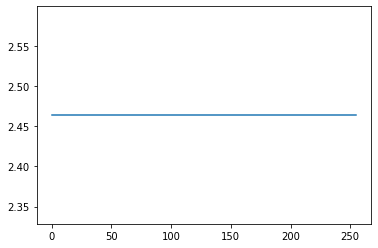

In [143]:
plt.plot(X[:,100,100])

In [144]:
#Get Y
Y = hf.get('Grid/Y')
print(Y)
Y = np.array(Y)
print(Y.shape)
#print(Y)

<HDF5 dataset "Y": shape (256, 192, 256), type "<f8">
(256, 192, 256)


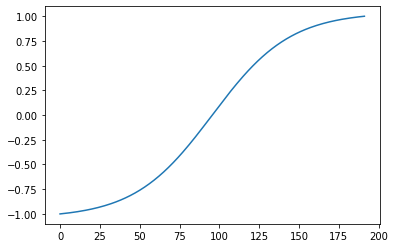

In [145]:
plt.plot(Y[200,:,200])

In [146]:
#Get Z
Z = hf.get('Grid/Z')
print(Z)
Z = np.array(Z)
print(Z.shape)
#print(Z)

<HDF5 dataset "Z": shape (256, 192, 256), type "<f8">
(256, 192, 256)


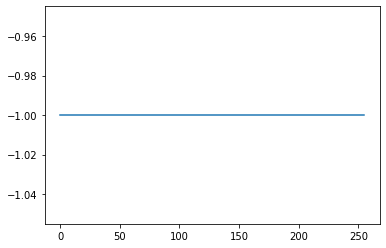

In [147]:
plt.plot(Y[0,0,:])

# Defining Filter

In [148]:
#Defining Filter (LES)
Filter = np.array([
                  [[0.125,0.25,0.125],
                   [0.25,0.5,0.25],
                   [0.125,0.25,0.125]],
                  [[0.25,0.5,0.25],
                   [0.5,1,0.5],
                   [0.25,0.5,0.25]],
                  [[0.125,0.25,0.125],
                   [0.25,0.5,0.25],
                   [0.125,0.25,0.125]]
                  ])

In [149]:
#Defining Filter Difference X direction
Filter_X = np.array([
                  [[0,0,0],
                   [0,0,0],
                   [0,0,0]],
                  [[0,0,0],
                   [-0.5,0,0.5],
                   [0,0,0]],
                  [[0,0,0],
                   [0,0,0],
                   [0,0,0]]
                  ])

In [150]:
#Defining Filter Difference Y direction
Filter_Y = np.array([
                  [[0,0,0],
                   [0,0,0],
                   [0,0,0]],
                  [[0,0.5,0],
                   [0,0,0],
                   [0,-0.5,0]],
                  [[0,0,0],
                   [0,0,0],
                   [0,0,0]]
                  ])

In [151]:
#Defining Filter Difference Z direction
Filter_Z = np.array([
                  [[0,0,0],
                   [0,-0.5,0],
                   [0,0,0]],
                  [[0,0,0],
                   [0,0,0],
                   [0,0,0]],
                  [[0,0,0],
                   [0,0.5,0],
                   [0,0,0]]
                  ])

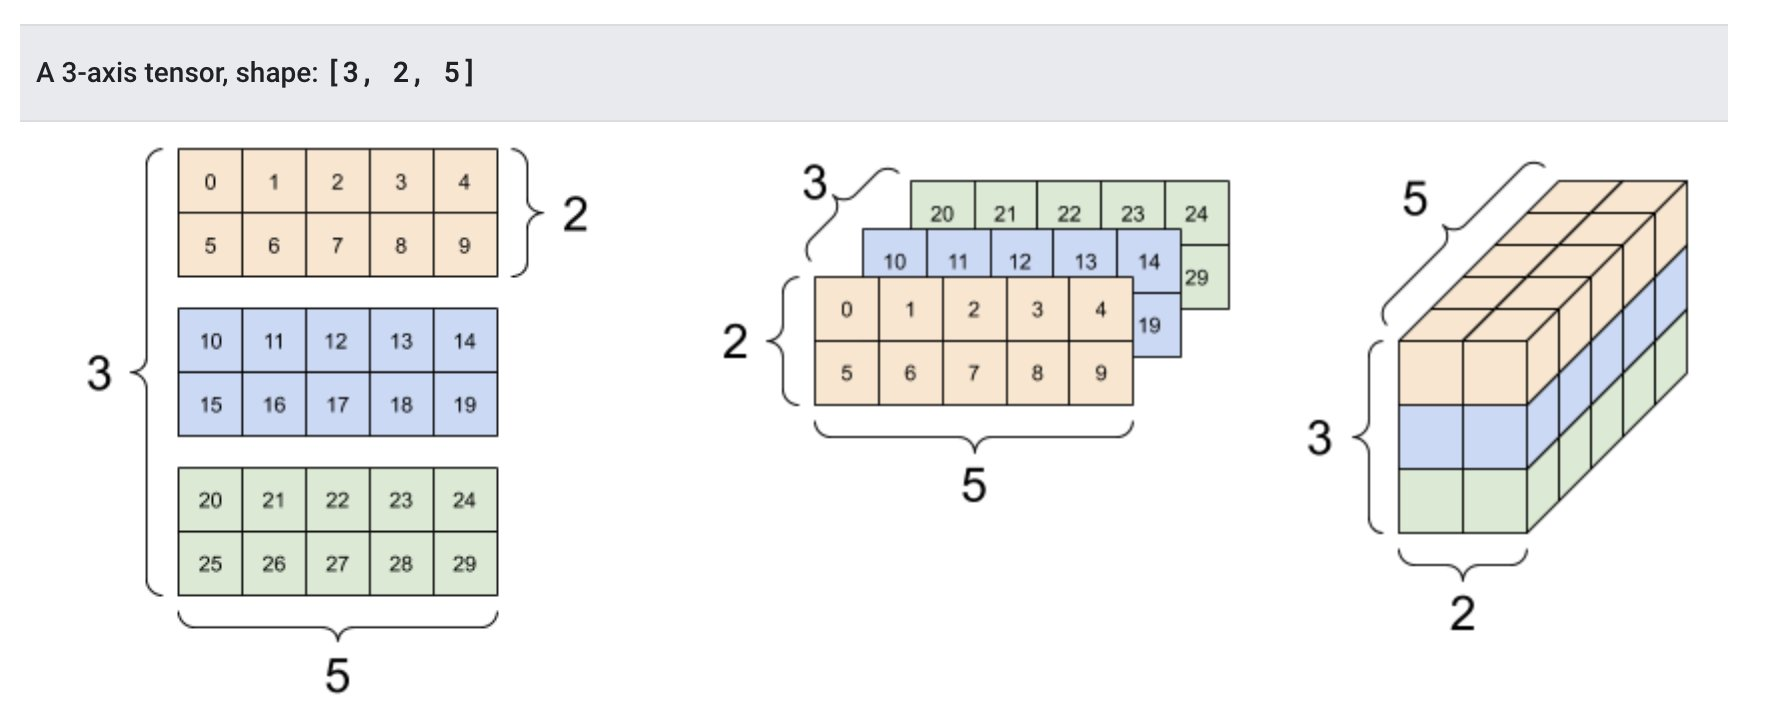

In [152]:
Filter_Z[0,1,1] #Checking z direction in tensor Filter_Z

-0.5

                                        Volume

In [153]:
FX=correlate(X, Filter_X, mode='reflect',output=float) #Warning Amin! mode has been changed to 'reflect' /////In this case mode='constant' is not true
 
np.shape(FX)

(256, 192, 256)

0.01231997119054902


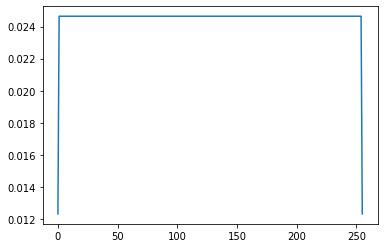

In [154]:
plt.plot(FX[0,0,:])
print(FX[0,0,0])
# plt.xlim([0, 100])
# plt.ylim([-2e-6, 2e-6])

In [155]:
FY=correlate(Y, Filter_Y, mode='reflect',output=float)
FY=np.absolute(FY) #because Y range is between [-1,1] and the results of Filter_Y are negative ==>> e.g. 0.5(0)-(-0.5)(-1) = -0.5
np.shape(FY)

(256, 192, 256)

0.0008433924216925126


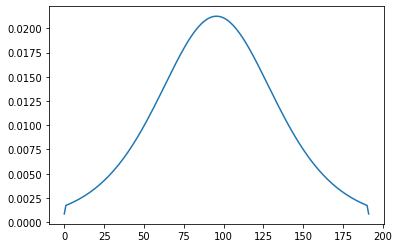

In [156]:
plt.plot(FY[10,:,10])
print(FY[0,0,0])
# plt.xlim([0, 100])
# plt.ylim([-2e-6, 2e-6])

In [157]:
FZ=correlate(Z, Filter_Z, mode='reflect',output=float)
np.shape(FZ)

(256, 192, 256)

0.01231997119054902


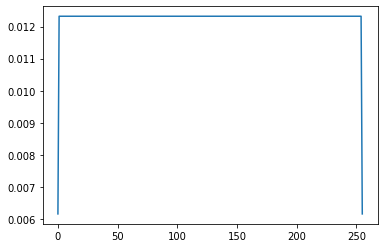

In [158]:
plt.plot(FZ[:,0,0])
print(FZ[1,0,0])
# plt.xlim([0, 100])
# plt.ylim([-2e-6, 2e-6])

In [159]:
volume=FX*FY*FZ # ELEMENTS' VOLUME TENSOR
np.shape(volume)

(256, 192, 256)

1.3056709345466386e-07


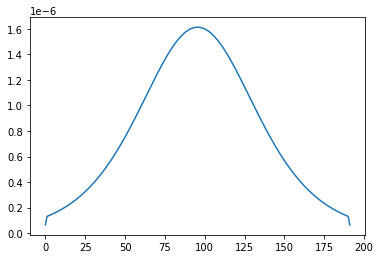

In [160]:
plt.plot(volume[0,:,0])
print(volume[0,1,0])

                                        Building volume*phi tensor ===> volume_U,V,W 

In [161]:
volume_U=volume*U 

In [162]:
volume_V=volume*V

In [163]:
volume_W=volume*W

                                        Building Filtered volume*phi tensor ===> F_volume_U,V,W 

In [164]:
F_volume_U=correlate(volume_U, Filter, mode='constant',output=float, cval=0.0)
np.shape(F_volume_U)

(256, 192, 256)

In [165]:
F_volume_V=correlate(volume_V, Filter, mode='constant',output=float, cval=0.0)
np.shape(F_volume_V)

(256, 192, 256)

In [166]:
F_volume_W=correlate(volume_W, Filter, mode='constant',output=float, cval=0.0)
np.shape(F_volume_W)

(256, 192, 256)

                                        Building Filtered volume tensor ===> F_volume 

In [167]:
F_volume=correlate(volume, Filter, mode='constant',output=float, cval=0.0)
np.shape(F_volume)

(256, 192, 256)

## Filtered U1, U2, U3 >>> FU1, FU2, FU3 

In [168]:
#U bar
FU1=F_volume_U/F_volume

In [169]:
#V bar
FU2=F_volume_V/F_volume

In [170]:
#W bar
FU3=F_volume_W/F_volume

## Calculation    Ui * Uj

In [171]:
U1U1=U*U

In [172]:
U1U2=U*V

In [173]:
U1U3=U*W

In [174]:
U2U2=V*V

In [175]:
U2U3=V*W

In [176]:
U3U3=W*W

## Calculation Filtered     Ui * Uj

                                            volume*UiUj

In [177]:
volume_U1U1=volume*U1U1

In [178]:
volume_U1U2=volume*U1U2

In [179]:
volume_U1U3=volume*U1U3

In [180]:
volume_U2U2=volume*U2U2

In [181]:
volume_U2U3=volume*U2U3

In [182]:
volume_U3U3=volume*U3U3

                                           Filtered volume*UiUj ===>  F_volume_UiUj 

In [183]:
F_volume_U1U1=correlate(volume_U1U1, Filter, mode='constant',output=float, cval=0.0)
np.shape(F_volume_U1U1)

(256, 192, 256)

In [184]:
F_volume_U1U2=correlate(volume_U1U2, Filter, mode='constant',output=float, cval=0.0)
np.shape(F_volume_U1U2)

(256, 192, 256)

In [185]:
F_volume_U1U3=correlate(volume_U1U3, Filter, mode='constant',output=float, cval=0.0)
np.shape(F_volume_U1U3)

(256, 192, 256)

In [186]:
F_volume_U2U2=correlate(volume_U2U2, Filter, mode='constant',output=float, cval=0.0)
np.shape(F_volume_U2U2)

(256, 192, 256)

In [187]:
F_volume_U2U3=correlate(volume_U2U3, Filter, mode='constant',output=float, cval=0.0)
np.shape(F_volume_U2U3)

(256, 192, 256)

In [188]:
F_volume_U3U3=correlate(volume_U3U3, Filter, mode='constant',output=float, cval=0.0)
np.shape(F_volume_U3U3)

(256, 192, 256)

                                            Filtered Ui*Uj

In [189]:
FU1U1=F_volume_U1U1/F_volume

In [190]:
FU1U2=F_volume_U1U2/F_volume

In [191]:
FU1U3=F_volume_U1U3/F_volume

In [192]:
FU2U2=F_volume_U2U2/F_volume

In [193]:
FU2U3=F_volume_U2U3/F_volume

In [194]:
FU3U3=F_volume_U3U3/F_volume

## Filtered Tau ij >>> FTij

In [195]:
FT11=FU1U1-(FU1*FU1)

In [196]:
FT12=FU1U2-(FU1*FU2)

In [197]:
FT13=FU1U3-(FU1*FU3)

In [198]:
FT22=FU2U2-(FU2*FU2)

In [199]:
FT23=FU2U3-(FU2*FU3)

In [200]:
FT33=FU3U3-(FU3*FU3)

# Difining inputs based on features

## Flatten FU1, FU2, FU3 

In [201]:
FU1_flat=FU1.flatten()
print(np.shape(FU1_flat))
print(FU1_flat)

(12582912,)
[0.31566623 0.31216495 0.32819133 ... 0.41219536 0.42553311 0.43903883]


In [202]:
FU2_flat=FU2.flatten()
print(np.shape(FU2_flat))
print(FU2_flat)

(12582912,)
[-0.00397946 -0.0056601  -0.00605891 ... -0.00096153  0.0005281
  0.00165223]


In [203]:
FU3_flat=FU3.flatten()
print(np.shape(FU3_flat))
print(FU3_flat)

(12582912,)
[ 0.09885145  0.07293871  0.04812083 ...  0.00490067 -0.0077739
 -0.01152505]


## Flatten FTij

In [204]:
FT11_flat=FT11.flatten()
print(np.shape(FT11_flat))
print(FT11_flat)

(12582912,)
[0.10050269 0.09873276 0.10992258 ... 0.16690782 0.17788936 0.18928543]


In [205]:
FT12_flat=FT12.flatten()
print(np.shape(FT12_flat))
print(FT12_flat)

(12582912,)
[-0.00108996 -0.00159424 -0.00176067 ... -0.00035742  0.00025079
  0.00072724]


In [206]:
FT13_flat=FT13.flatten()
print(np.shape(FT13_flat))
print(FT13_flat)

(12582912,)
[ 0.02880791  0.01964416  0.01249426 ...  0.00158768 -0.00340195
 -0.00501589]


In [207]:
FT22_flat=FT22.flatten()
print(np.shape(FT22_flat))
print(FT22_flat)

(12582912,)
[2.61909453e-05 4.18549007e-05 4.58530285e-05 ... 5.32698435e-06
 4.59524087e-06 5.23320169e-06]


In [208]:
FT23_flat=FT23.flatten()
print(np.shape(FT23_flat))
print(FT23_flat)

(12582912,)
[-3.88039217e-04 -4.49159143e-04 -4.02665023e-04 ... -4.53073485e-05
 -1.23456271e-05 -7.91233014e-06]


In [209]:
FT33_flat=FT33.flatten()
print(np.shape(FT33_flat))
print(FT33_flat)

(12582912,)
[0.01305054 0.00892271 0.00467785 ... 0.000608   0.00021564 0.00028802]


                                       
                                       
                                       
                                       #### Plot histogram FTij_flat####

0.0001832069560809876


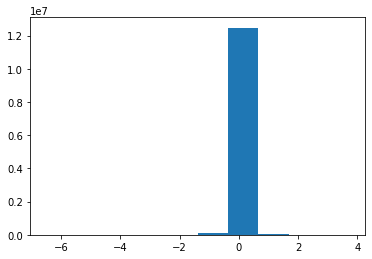

In [222]:
plt.hist(FT12_flat)
print(np.mean(FT12_flat))

## X_input & Data initialization

## X_input
## Stacking 1D arrays U1 U2 U3 >>> Build 2D array & Dimension=(-1,3)

In [76]:
X_input=np.vstack((FU1_flat,FU2_flat,FU3_flat))
X_input=X_input.T #Transpose X_input >>> Dimension = (-1,3)
np.shape(X_input)
#print(X_input)

(12582912, 3)

In [77]:
# '''Mean of X_input'''
# mu = np.mean(X_input, axis=0)
# print(mu.shape)
# print(mu)
# '''Standard deviation'''
# xstd=np.std(X_input,axis=0)
# print(xstd.shape)
# print(xstd)

In [78]:
# '''Standardization X_input'''
# X_input_stzd=X_input
# X_input_stzd-=mu
# X_input_stzd/=xstd
# # print(X_input_stzd)
# #plt.plot(X_input_stzd[:,2])
# plt.hist(X_input_stzd[:,0])

In [79]:
# import numpy as np

# from sklearn import preprocessing

# X = np.array([
#     [ 0,  1],
#     [ 2,  3],
#     [ 4,  5],
#     [ 6,  7],
#     [ 8,  9],
#     [10, 11],
#     [12, 13],
#     [14, 15]
# ])

# min_max_scaler = preprocessing.MinMaxScaler()

# scaled_x = min_max_scaler.fit_transform(X)

# scaled_x

In [80]:
def NormalizeData(data):
    return (data - np.min(data,axis=0)) / (np.max(data,axis=0) - np.min(data,axis=0))

In [81]:
X_input_stzd=NormalizeData(X_input)

(array([ 546745.,  451399.,  455910.,  518582.,  691623., 1151259.,
        1975165., 2670149., 3182506.,  939574.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

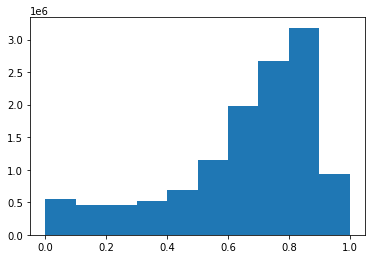

In [82]:
plt.hist(X_input_stzd[:,0])

(array([5.400000e+01, 3.871000e+03, 1.046180e+05, 9.930810e+05,
        4.820865e+06, 5.468691e+06, 1.060852e+06, 1.231460e+05,
        7.424000e+03, 3.100000e+02]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

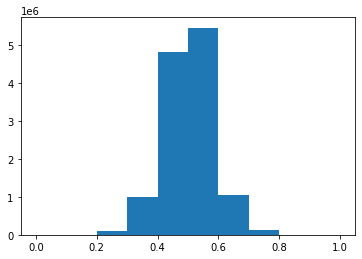

In [83]:
plt.hist(X_input_stzd[:,1])

(array([5.880000e+02, 1.469900e+04, 2.123560e+05, 1.571075e+06,
        5.733621e+06, 4.115326e+06, 8.448230e+05, 8.436500e+04,
        5.781000e+03, 2.780000e+02]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

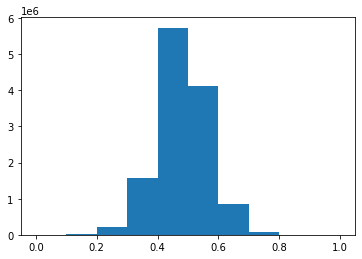

In [84]:
plt.hist(X_input_stzd[:,2])

## Y_output

In [85]:
Y_output_FT11=FT11_flat

In [86]:
Y_output_FT12=FT12_flat

In [87]:
Y_output_FT13=FT13_flat

In [88]:
Y_output_FT22=FT22_flat

In [89]:
Y_output_FT23=FT23_flat

In [90]:
Y_output_FT33=FT33_flat

                                       Warning Amin!
                                     (Y Normalization)
                                     Y_output_FTij_stzd

In [91]:
Y_output_FT11_stzd=NormalizeData(Y_output_FT11)

In [92]:
Y_output_FT12_stzd=NormalizeData(Y_output_FT12)

In [93]:
Y_output_FT13_stzd=NormalizeData(Y_output_FT13)

In [94]:
Y_output_FT22_stzd=NormalizeData(Y_output_FT22)

In [95]:
Y_output_FT23_stzd=NormalizeData(Y_output_FT23)

In [96]:
Y_output_FT33_stzd=NormalizeData(Y_output_FT33)

(array([1.2252677e+07, 2.7105800e+05, 4.5100000e+04, 1.0077000e+04,
        2.7540000e+03, 9.0400000e+02, 2.5500000e+02, 6.0000000e+01,
        1.8000000e+01, 9.0000000e+00]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

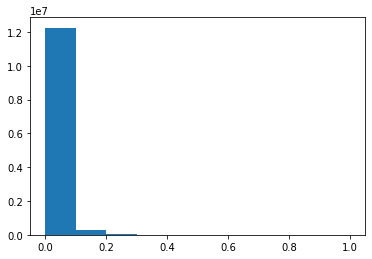

In [97]:
plt.hist(Y_output_FT11_stzd)

                                        Y_output

                        Stacking 6 1D arrays FTij_flat  >>> Build 2D array & Dimension=(-1,6)

In [98]:
Y_output=np.vstack((FT11_flat,FT12_flat,FT13_flat,FT22_flat,FT23_flat,FT33_flat))
Y_output=Y_output.T #Transpose Y_output >>> Dimension = (-1,3)
np.shape(Y_output)
#print(X_input)

(12582912, 6)

# X_train & Y_train   * * * * * * * * * *   X_test & Y_test

In [99]:
from sklearn.model_selection import train_test_split

In [100]:
#  x_train, x_test, y_train, y_test = train_test_split(x, y)
# Fraction of Data used for training = 0.8 
X_train, X_test, Y_train, Y_test = train_test_split(X_input_stzd, Y_output,train_size=0.9,test_size=0.1,random_state=None,
    shuffle=True,)

In [101]:
np.shape(X_train)

(11324620, 3)

In [102]:
np.shape(Y_train)

(11324620, 6)

# ANN

                                         Builing the Model

In [103]:
# from keras.models import Sequential
# from keras.layers import BatchNormalization, Dropout
# from keras.layers import Activation

# from keras.models import Input, Model
# from keras.layers import Dense, Dropout



# model = Sequential()

# # First Hidden Layer
# model.add(Dense(units=64, input_shape=(3,)))
# model.add(BatchNormalization())
# model.add(Activation(activation='selu'))
# model.add(Dropout(0.2))

# # Second Hidden Layer
# model.add(Dense(units=64))
# model.add(BatchNormalization())
# model.add(Activation(activation='selu'))
# model.add(Dropout(0.2))

# # Third Hidden Layer
# model.add(Dense(units=64))
# model.add(BatchNormalization())
# model.add(Activation(activation='selu'))
# model.add(Dropout(0.2))

# # # Forth Hidden Layer
# # model.add(Dense(units=30))
# # # model.add(BatchNormalization())
# # model.add(Activation(activation='selu'))
# # # model.add(Dropout(0.2))

# # # Forth Hidden Layer
# # model.add(Dense(units=30))
# # # model.add(BatchNormalization())
# # model.add(Activation(activation='selu'))
# # # model.add(Dropout(0.2))

# # # Forth Hidden Layer
# # model.add(Dense(units=30))
# # # model.add(BatchNormalization())
# # model.add(Activation(activation='selu'))
# # # model.add(Dropout(0.2))

# # # Forth Hidden Layer
# # model.add(Dense(units=30))
# # # model.add(BatchNormalization())
# # model.add(Activation(activation='selu'))
# # # model.add(Dropout(0.2))

# # # Forth Hidden Layer
# # model.add(Dense(units=30))
# # # model.add(BatchNormalization())
# # model.add(Activation(activation='selu'))
# # # model.add(Dropout(0.2))


# # # Forth Hidden Layer
# # model.add(Dense(units=30))
# # # model.add(BatchNormalization())
# # model.add(Activation(activation='selu'))
# # # model.add(Dropout(0.2))


# # # Forth Hidden Layer
# # model.add(Dense(units=30))
# # # model.add(BatchNormalization())
# # model.add(Activation(activation='selu'))
# # # model.add(Dropout(0.2))

# # # Forth Hidden Layer
# # model.add(Dense(units=30))
# # # model.add(BatchNormalization())
# # model.add(Activation(activation='selu'))
# # # model.add(Dropout(0.2))






# # Output Layer
# model.add(Dense(units=6, activation='linear'))

# # print model
# model.summary()

In [378]:
from tensorflow import keras
from keras.models import Input, Model
from keras.layers import Dense, Dropout



model_in  = Input(shape=(3,))

#Hidden Layers
hidden1 = Dense(40, activation="relu")(model_in)
hidden2 = Dense(40, activation="relu")(hidden1)
# hidden3 = Dense(64, activation="selu")(hidden2)
#hidden4 = Dense(64, activation="selu")(hidden3)
#OutputLayer
model_out = Dense(6, activation='linear')(hidden2)


model = Model(inputs=model_in, outputs=model_out)

model.summary()

Model: "model_18"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_19 (InputLayer)       [(None, 3)]               0         
                                                                 
 dense_54 (Dense)            (None, 40)                160       
                                                                 
 dense_55 (Dense)            (None, 40)                1640      
                                                                 
 dense_56 (Dense)            (None, 6)                 246       
                                                                 
Total params: 2,046
Trainable params: 2,046
Non-trainable params: 0
_________________________________________________________________


                                        Defining the Model

                                        Compiling the Model

In [379]:
## plot graph
##from keras.utils import plot_model
## plot_model(model, to_file='multilayer_perceptron_graph.png')

#                                        Custom Loss Function

In [380]:
# import tensorflow as tf
# def custom_loss_function(y_true, y_pred):
#    squared_difference = tf.square(y_true - y_pred)
#    return tf.reduce_mean(squared_difference)

Warning Amin! In model.compile ===> loss=costum_mse     ( without '    ' )

In [381]:
# import keras.backend as K  

# #Warning Amin! In model.compile ===> loss=costum_mse ( without ' ' )

# def costum_mse(y_true,y_pred):
#     loss = K.square(y_pred - y_true)
#     scaled_loss = loss/K.abs(y_true)
#     scale_mse_loss = K.switch((y_pred[0] < y_pred[1]),scaled_loss,loss)

#   #  scale_mse_loss = K.switch((y_pred[0] < 100000000000),scaled_loss,loss)
#   #  scale_mse_loss = K.switch((y_pred[0] > 0 ),scaled_loss,loss) # just last line runs
#     return scale_mse_loss

We are not able to use if in our loss function. because if doesn't have derivative (backpropagation)

In [382]:
# import keras.backend as K


# def scaled_mse(y_true,y_pred):
#     loss=K.square(y_pred - y_true)
#     scaled_loss = loss/K.abs(y_true)
 #######We are not able to use if in our loss function. because if doesn't have derivative (backpropagation)#######   
#     if y_pred[0] < 100000000000:
#         scale_mse_loss=scaled_loss
#     else:
#         scale_mse_loss=loss
#     return scale_mse_loss

                                        Model compile

In [383]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adamax(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07, name="Adamax"),
                   #How the model learns
    loss='mse',                         #'MeanSquaredError',#'BinaryCrossentropy',  #how to model judges itself
    )


In [384]:
# tf.keras.optimizers.Adadelta(learning_rate=0.01, rho=0.95, epsilon=1e-07, name="Adadelta"),
#tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.0, nesterov=False, name="SGD")
#tf.keras.optimizers.RMSprop(learning_rate=0.001,rho=0.9,momentum=0.0,epsilon=1e-07,centered=False,name="RMSprop")
#tf.keras.optimizers.Adagrad(learning_rate=0.001,initial_accumulator_value=0.1,epsilon=1e-07,name="Adagrad")
#tf.keras.optimizers.Adadelta(learning_rate=0.001, rho=0.95, epsilon=1e-07, name="Adadelta")
#tf.keras.optimizers.Adamax(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07, name="Adamax")

                                        Fitting the Model

In [385]:
# import tensorflow as tf
# reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.2,
#     patience=5,
#     verbose=0,
#     mode='auto',
#     min_delta=0.0001,
#     cooldown=0,
#     min_lr=0.001,)


In [386]:

history = model.fit(
    x = X_train,                                 #data that get
    y = Y_train,                                #output we are expection
#     callbacks=[reduce_lr],
    validation_data = (X_test, Y_test),
    epochs = 20,                                     #How many times the model runs through
    verbose = 1,                                     #when this = 1, includes progress bar. 2, excludes progress bar
    batch_size=10000,
    shuffle=True
)

Epoch 1/20
1133/1133 [==============================] - 5s 4ms/step - loss: 0.0304 - val_loss: 0.0290
Epoch 2/20
1133/1133 [==============================] - 5s 4ms/step - loss: 0.0291 - val_loss: 0.0288
Epoch 3/20
1133/1133 [==============================] - 5s 4ms/step - loss: 0.0290 - val_loss: 0.0287
Epoch 4/20
1133/1133 [==============================] - 5s 4ms/step - loss: 0.0289 - val_loss: 0.0287
Epoch 5/20
1133/1133 [==============================] - 5s 4ms/step - loss: 0.0289 - val_loss: 0.0286
Epoch 6/20
1133/1133 [==============================] - 4s 4ms/step - loss: 0.0288 - val_loss: 0.0286
Epoch 7/20
1133/1133 [==============================] - 4s 4ms/step - loss: 0.0288 - val_loss: 0.0285
Epoch 8/20
1133/1133 [==============================] - 4s 4ms/step - loss: 0.0288 - val_loss: 0.0285
Epoch 9/20
1133/1133 [==============================] - 5s 4ms/step - loss: 0.0288 - val_loss: 0.0285
Epoch 10/20
1133/1133 [==============================] - 4s 4ms/step - loss: 0.028

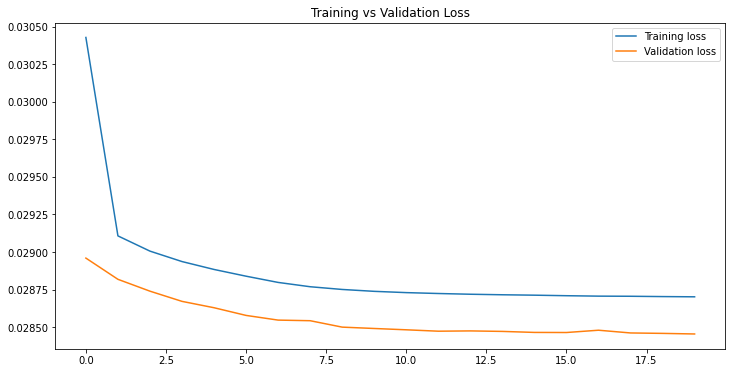

In [387]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label="Training loss")
plt.plot(history.history['val_loss'], label="Validation loss")
plt.legend()
plt.title("Training vs Validation Loss")
#plt.ylim([0, 200])
plt.show()

In [388]:
from sklearn.metrics import mean_squared_error

def sum_mse_tau(Y_train):
    ttt=np.shape(Y_train)
    zero_Ytrain=np.zeros(ttt)
    MSE_Ytrain=np.zeros(ttt[1])
    for i in range(0,ttt[1]):
        MSE_Ytrain[i]=mean_squared_error(Y_train[:,i],zero_Ytrain[:,i])
    total_sum=np.sum(MSE_Ytrain)
    return total_sum


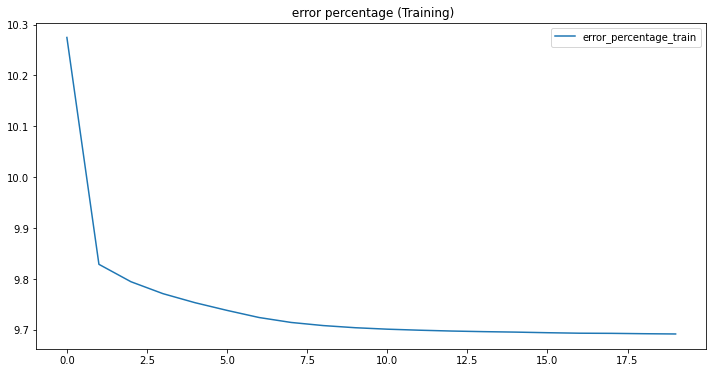

In [389]:
plt.figure(figsize=(12, 6))
percentage_error_train=(history.history['loss'])/sum_mse_tau(Y_train)*100
percentage_error_val=(history.history['val_loss'])/sum_mse_tau(Y_test)*100

plt.plot(percentage_error_train, label="error_percentage_train")
plt.plot(percentage_error_val, label="error_percentage_val",color='red')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('% error')
plt.title(" error percentage (Training & Validation)")

plt.show()

In [390]:
'''====================[Saving Data]===================='''
#Saves the model weights and biases
weights = []
biases = []

i=0

#4 is the number of layers, 1 is the index of the first hidden later
for i in range(1,4): 
    weights.append(model.layers[i].get_weights()[0])
    biases.append(model.layers[i].get_weights()[1])


#saves weights and biases as .mpy files for use within python
np.save("weights/all_weights", weights)#, fmt='%s')
np.save("biases/all_biases",   biases)#, fmt='%s')


# #Saves predicted and actual output arrays as .txt files for future use or comparison
# np.savetxt("output_arrays/pred_rxn_array.txt", pred_arr)
# np.savetxt("output_arrays/exact_rxn_array.txt", output_test)
        

C:\Users\user\anaconda3\envs\AminAnaconda\lib\site-packages\numpy\lib\npyio.py:518: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = np.asanyarray(arr)


In [391]:
np.shape(weights)
print(weights)

[array([[ 0.1041204 , -0.3837105 ,  0.37780884,  0.02744835,  0.01660131,
        -0.36983925, -0.07196031, -0.2819873 , -0.2682777 ,  0.27009073,
         0.16560507,  0.3856904 ,  0.31666702, -0.13102427,  0.22798245,
         0.02833234, -0.19766657, -0.11874608,  0.12866625, -0.03524637,
         0.38210255,  0.0459496 , -0.35196677, -0.04735845, -0.07713571,
        -0.40063402, -0.08076493,  0.09275241, -0.2728227 ,  0.10150886,
         0.40325427,  0.23728703, -0.1263302 , -0.533942  ,  0.3350034 ,
         0.13894403,  0.02672667,  0.1464068 ,  0.4090972 ,  0.28879067],
       [-0.02721638,  0.1000974 ,  0.01062289,  0.31602344,  0.0174236 ,
         0.11195379,  0.30529147,  0.02565146,  0.21864985,  0.20332177,
        -0.3726798 , -0.08394188, -0.21159525,  0.0195365 , -0.01881238,
         0.2537763 ,  0.16466764,  0.00839858,  0.035028  , -0.11465374,
         0.0972573 , -0.5121001 ,  0.32592487,  0.02246315, -0.2702468 ,
         0.15796214, -0.21129042,  0.3848841 , -0

C:\Users\user\anaconda3\envs\AminAnaconda\lib\site-packages\numpy\core\fromnumeric.py:2007: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  result = asarray(a).shape


In [392]:
aaa=model.layers[1].get_weights()[0]
print(np.shape(aaa))
print(aaa)

(3, 40)
[[ 0.1041204  -0.3837105   0.37780884  0.02744835  0.01660131 -0.36983925
  -0.07196031 -0.2819873  -0.2682777   0.27009073  0.16560507  0.3856904
   0.31666702 -0.13102427  0.22798245  0.02833234 -0.19766657 -0.11874608
   0.12866625 -0.03524637  0.38210255  0.0459496  -0.35196677 -0.04735845
  -0.07713571 -0.40063402 -0.08076493  0.09275241 -0.2728227   0.10150886
   0.40325427  0.23728703 -0.1263302  -0.533942    0.3350034   0.13894403
   0.02672667  0.1464068   0.4090972   0.28879067]
 [-0.02721638  0.1000974   0.01062289  0.31602344  0.0174236   0.11195379
   0.30529147  0.02565146  0.21864985  0.20332177 -0.3726798  -0.08394188
  -0.21159525  0.0195365  -0.01881238  0.2537763   0.16466764  0.00839858
   0.035028   -0.11465374  0.0972573  -0.5121001   0.32592487  0.02246315
  -0.2702468   0.15796214 -0.21129042  0.3848841  -0.05458322  0.2258201
   0.05725558  0.20386147 -0.32671535  0.01976795  0.25781217  0.12903088
   0.05754141 -0.41003639  0.06055476  0.27670816]
 [-0